# Model 1 — MLP (Classical Baseline)

**Owner:** Advait Gujar (230911404)

> **Depends on:** run `00_shared_pipeline.ipynb` first, in the same kernel (it builds `train_df`/`val_df`/`test_df`, the DataLoaders, `pos_weights`, `criterion`, and the shared `train_model`/`evaluate` functions used below).

## Architecture

Flattens the image to a single vector and classifies with fully connected layers — no convolutional structure, no spatial inductive bias. This is the classical-family baseline the other three architectures are compared against.

In [1]:
# --- Model 1: MLP (Classical baseline) ---
class MLPBaseline(nn.Module):
    def __init__(self, num_classes=5, img_size=224, dropout=0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(3*img_size*img_size, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(self.flatten(x))

print("MLP params:", sum(p.numel() for p in MLPBaseline().parameters()))

MLP params: 77137157


## Train

In [2]:
mlp_model = MLPBaseline(num_classes=len(DISEASE_COLS), img_size=IMG_SIZE)
mlp_model, mlp_history = train_model(mlp_model, 'mlp', freeze_schedule=False)

[mlp] Epoch 1/5  Train Loss: 1.0514  Train AUC: 0.5898  Val Loss: 1.0146  Val AUC: 0.6314
[mlp] Epoch 2/5  Train Loss: 1.0139  Train AUC: 0.6183  Val Loss: 0.9987  Val AUC: 0.6415
[mlp] Epoch 3/5  Train Loss: 1.0042  Train AUC: 0.6284  Val Loss: 0.9861  Val AUC: 0.6498
[mlp] Epoch 4/5  Train Loss: 0.9959  Train AUC: 0.6376  Val Loss: 0.9826  Val AUC: 0.6556
[mlp] Epoch 5/5  Train Loss: 0.9897  Train AUC: 0.6449  Val Loss: 0.9796  Val AUC: 0.6606


In [11]:
import json
with open(os.path.join(OUTPUT_DIR, 'mlp_history.json'), 'w') as f:
    json.dump(mlp_history, f)

## Evaluate on Test Set

In [4]:
# Get MLP's predictions on the test set
_, mlp_test_auc, mlp_test_labels, mlp_test_preds = evaluate(mlp_model, test_loader, criterion)
print(f"MLP Test Mean AUC: {mlp_test_auc:.4f}")

# ROC curve (micro-averaged across all 5 diseases)
fpr, tpr, _ = roc_curve(mlp_test_labels.ravel(), mlp_test_preds.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'MLP (AUC = {roc_auc:.3f})', color='tab:blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — MLP (Micro-Averaged Across 5 Diseases)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(mlp_test_labels.ravel(), mlp_test_preds.ravel())
ap = average_precision_score(mlp_test_labels, mlp_test_preds, average='micro')

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f'MLP (AP = {ap:.3f})', color='tab:blue', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — MLP (Micro-Averaged)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

MLP Test Mean AUC: 0.6608


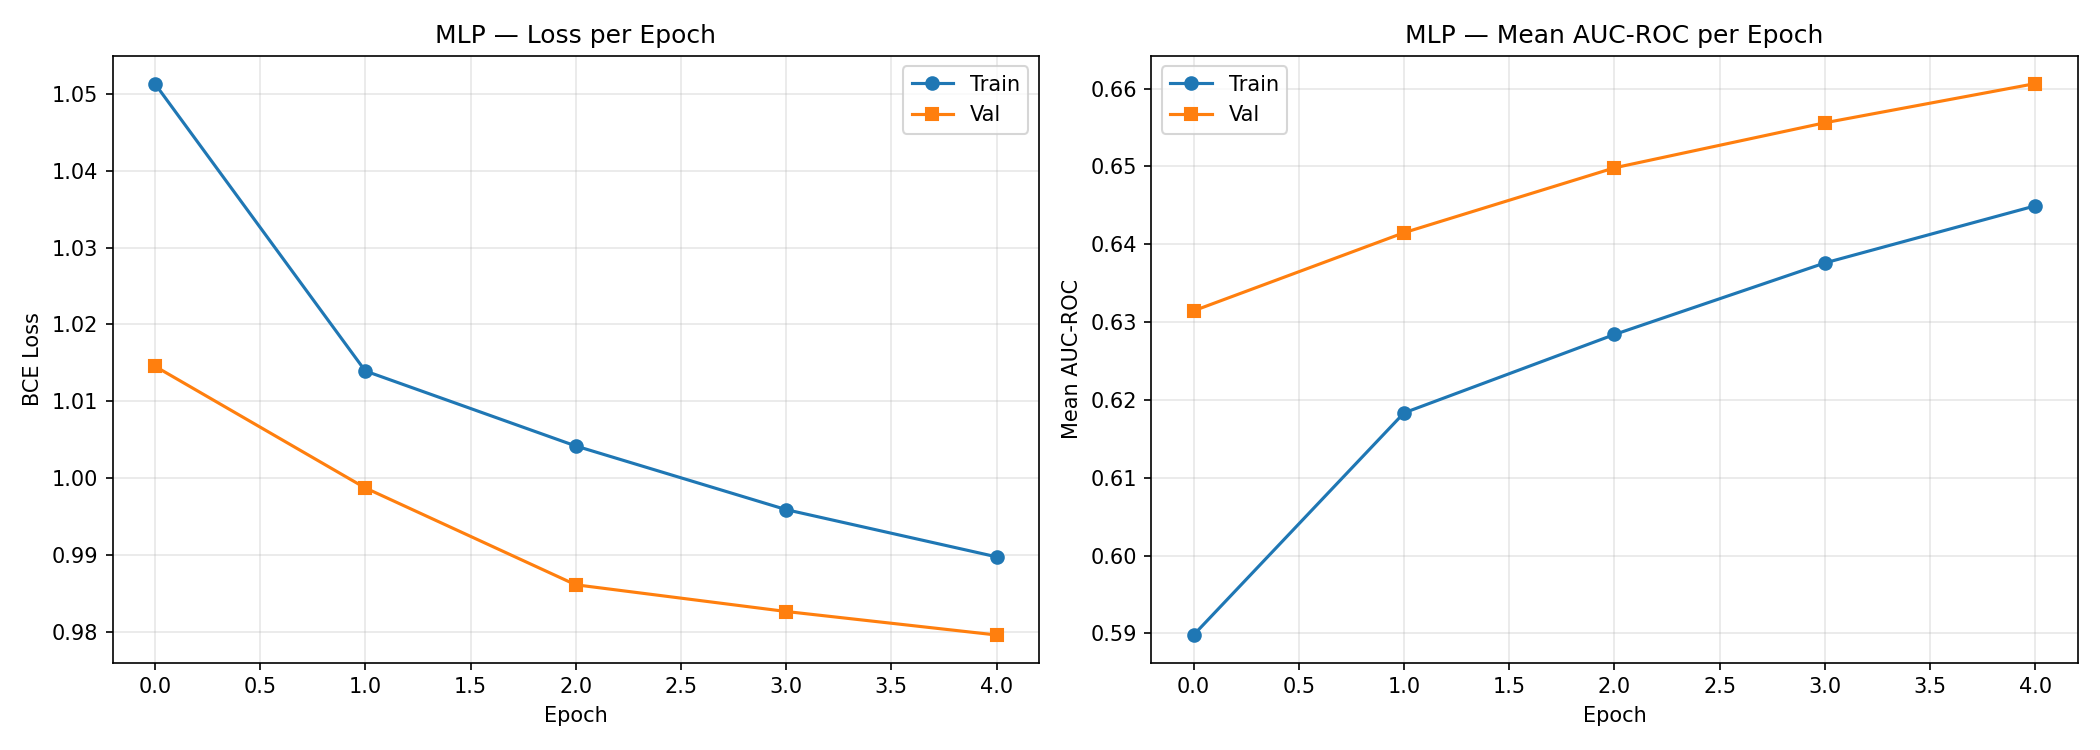

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_history['train_loss'], marker='o', label='Train')
axes[0].plot(mlp_history['val_loss'], marker='s', label='Val')
axes[0].set_title('MLP — Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(mlp_history['train_auc'], marker='o', label='Train')
axes[1].plot(mlp_history['val_auc'], marker='s', label='Val')
axes[1].set_title('MLP — Mean AUC-ROC per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC-ROC')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_loss_auc_curves.png'), dpi=150)
plt.show()

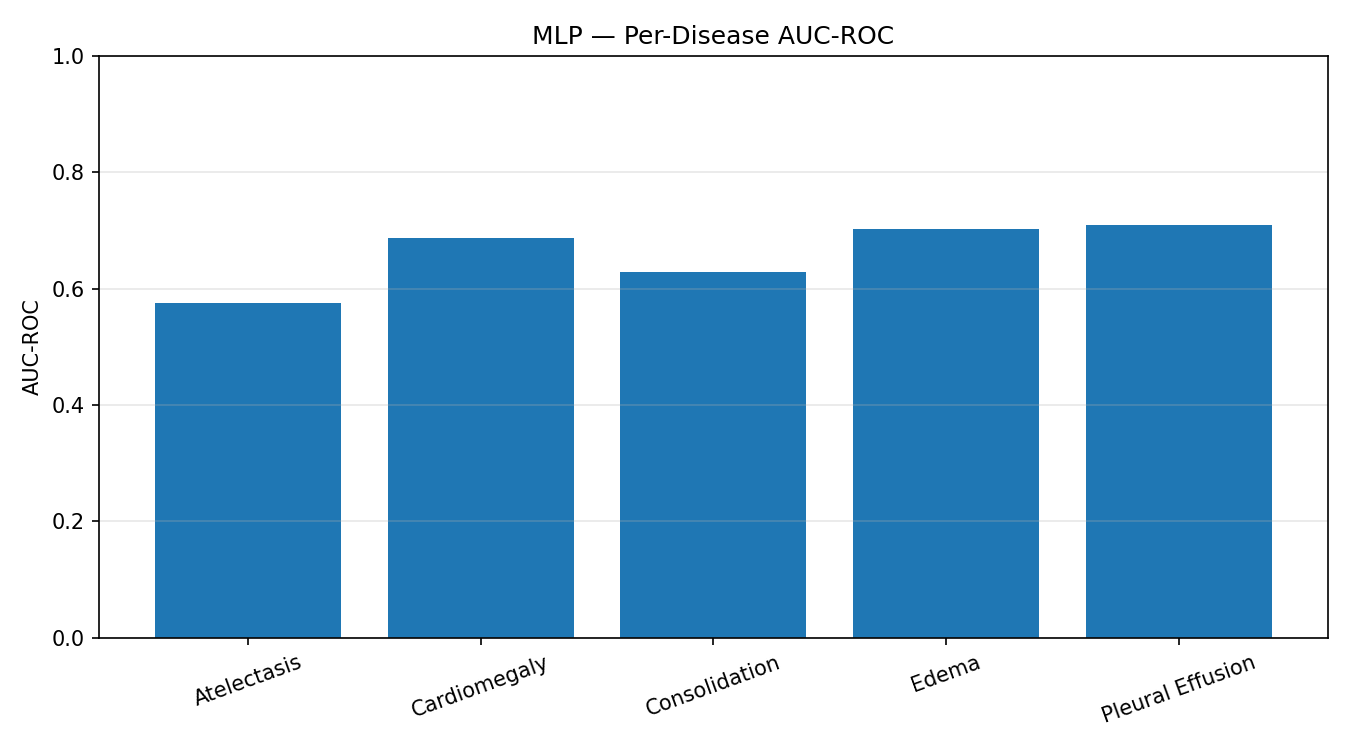

In [6]:
def _per_disease_auc(labels, preds):
    aucs = []
    for i in range(labels.shape[1]):
        try:
            aucs.append(roc_auc_score(labels[:, i], preds[:, i]))
        except Exception:
            aucs.append(0.0)
    return aucs

mlp_per_disease = _per_disease_auc(mlp_test_labels, mlp_test_preds)

plt.figure(figsize=(9, 5))
plt.bar(DISEASE_COLS, mlp_per_disease, color='tab:blue')
plt.ylabel('AUC-ROC'); plt.ylim(0, 1.0)
plt.title('MLP — Per-Disease AUC-ROC')
plt.xticks(rotation=20)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_per_disease_auc.png'), dpi=150)
plt.show()

for d, a in zip(DISEASE_COLS, mlp_per_disease):
    print(f"{d:20s}: {a:.4f}")

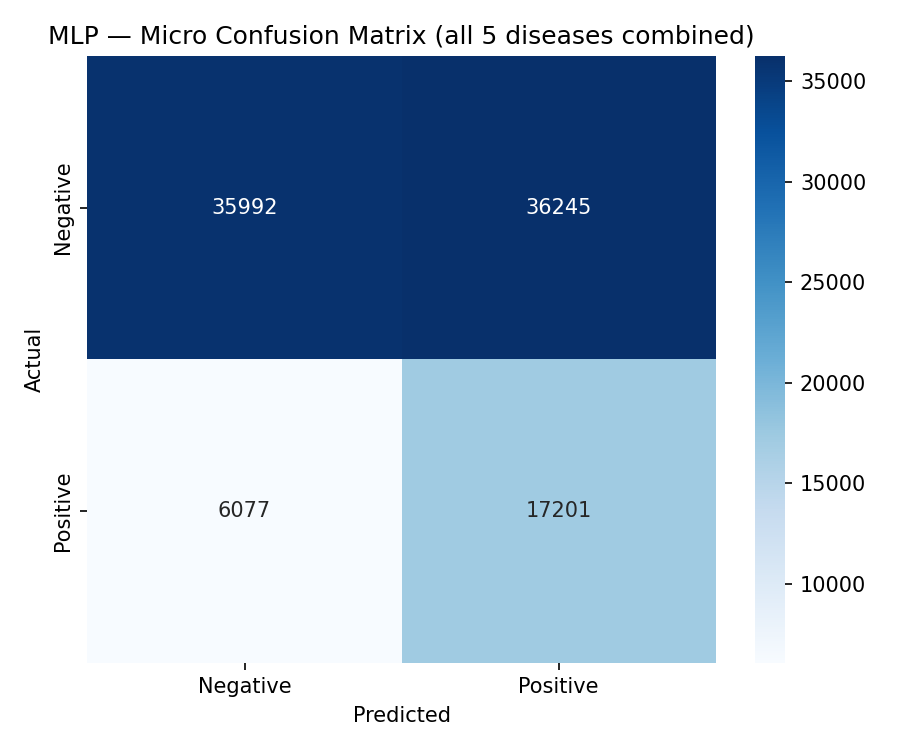

In [7]:
mlp_binary_preds = (mlp_test_preds >= 0.5).astype(int)
mlp_cm = confusion_matrix(mlp_test_labels.ravel(), mlp_binary_preds.ravel())

plt.figure(figsize=(6, 5))
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('MLP — Micro Confusion Matrix (all 5 diseases combined)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_confusion_matrix.png'), dpi=150)
plt.show()